In [1]:
from neuromaps import NeuroMapOriginal, NeuroMapFixed

model_original = NeuroMapOriginal.load("checkpoints/original/model.ckpt")
fixed_model = NeuroMapFixed.load("checkpoints/fixed/model.ckpt")

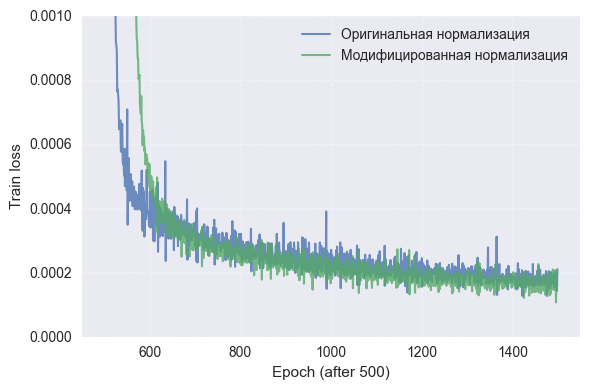

In [8]:
import matplotlib.pyplot as plt
import numpy as np

hist_o = model_original.training_history
hist_f = fixed_model.training_history

plt.style.use("seaborn-v0_8")
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.plot(np.arange(500, 500+len(hist_o["train_loss"])), hist_o["train_loss"],
        label="Оригинальная нормализация", lw=1.5, alpha=.8)
ax.plot(np.arange(500, 500+len(hist_f["train_loss"])), hist_f["train_loss"],
        label="Модифицированная нормализация", lw=1.5, alpha=.8)

ax.set_xlabel(f"Epoch (after 500)")
ax.set_ylabel("Train loss")
ax.legend()
ax.grid(True, ls="--", alpha=.3)
plt.ylim([0, 0.001])
plt.tight_layout()
plt.show()

Симуляция: 100%|██████████████████████████████████████████| 20000/20000 [00:00<00:00, 24421.43шаг/s]


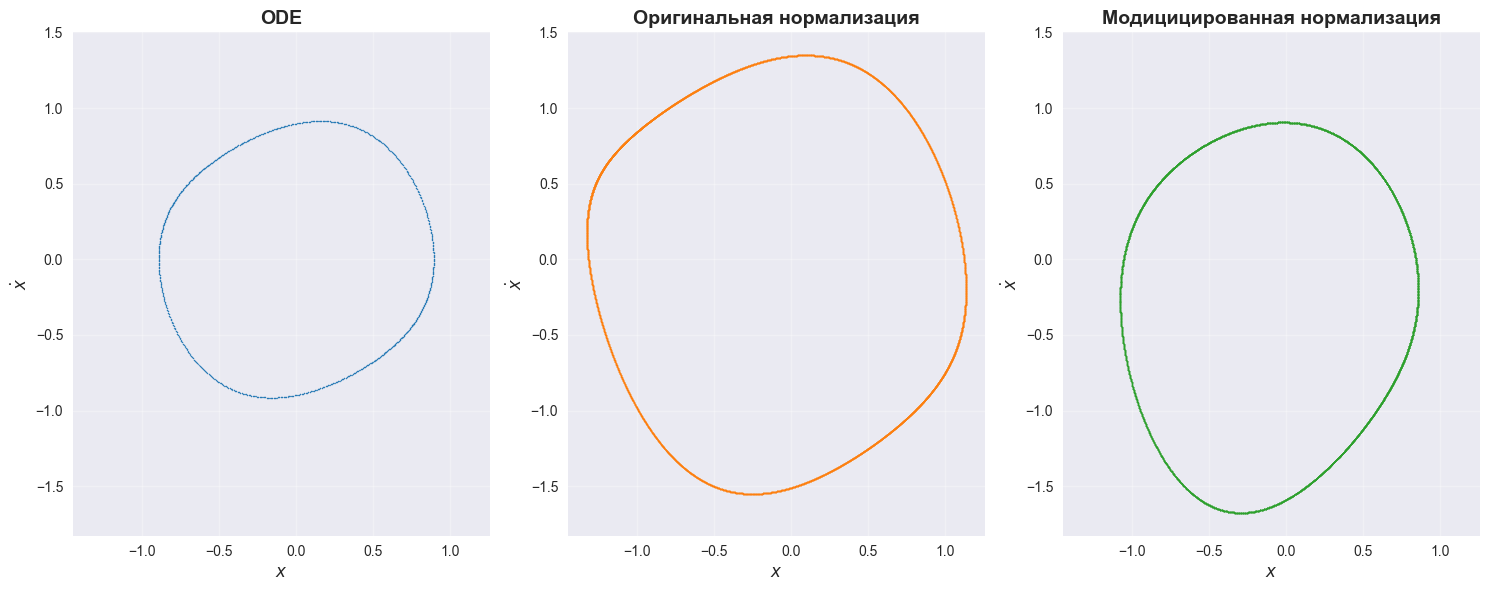

In [10]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import van_der_pol_rk4, van_der_pol_right_part

u0 = [0.5, 0.7]
p = [0.2, 1]

nm_long_traj = model_original.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)
nm_short_traj = fixed_model.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)
ode_traj = get_attractor_trajectory(
    van_der_pol_rk4, van_der_pol_right_part, u0, p, 0.01, 50, 50, 
    lambda x, y: x[1], lambda x, y: [0, 1], divergence_threshold=1e3
)

if nm_long_traj is not None:
    nm_long_traj = nm_long_traj[10000:]
if nm_short_traj is not None:
    nm_short_traj = nm_short_traj[10000:]

plot_compare_trajectories(
    ode_traj, nm_long_traj, nm_short_traj, 
    labels=['ODE', 'Оригинальная нормализация', 'Модицицированная нормализация'],
    layout='sidebyside'
)

Симуляция: 100%|██████████████████████████████████████████| 20000/20000 [00:00<00:00, 23918.41шаг/s]


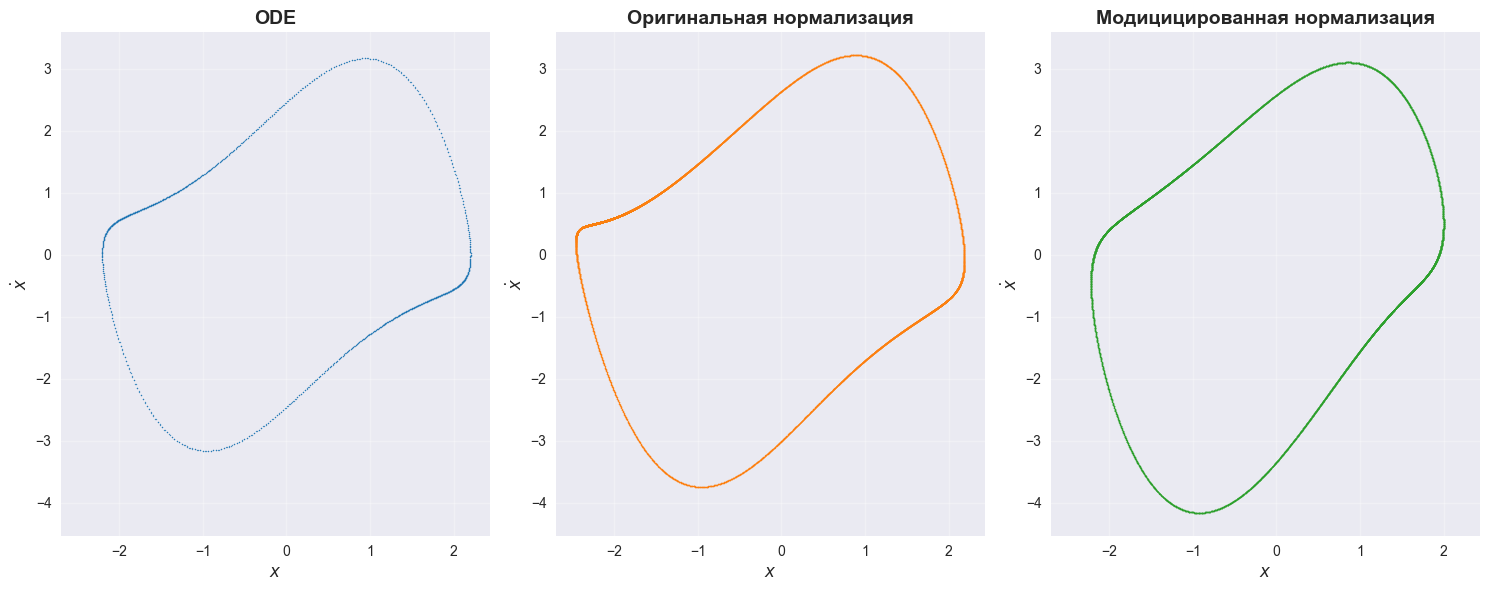

In [11]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import van_der_pol_rk4, van_der_pol_right_part

u0 = [0.5, 0.7]
p = [1.2, 1]

nm_long_traj = model_original.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)
nm_short_traj = fixed_model.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)
ode_traj = get_attractor_trajectory(
    van_der_pol_rk4, van_der_pol_right_part, u0, p, 0.01, 50, 50, 
    lambda x, y: x[1], lambda x, y: [0, 1], divergence_threshold=1e3
)

if nm_long_traj is not None:
    nm_long_traj = nm_long_traj[10000:]
if nm_short_traj is not None:
    nm_short_traj = nm_short_traj[10000:]

plot_compare_trajectories(
    ode_traj, nm_long_traj, nm_short_traj, 
    labels=['ODE', 'Оригинальная нормализация', 'Модицицированная нормализация'],
    layout='sidebyside'
)

Симуляция: 100%|██████████████████████████████████████████| 20000/20000 [00:00<00:00, 25013.20шаг/s]


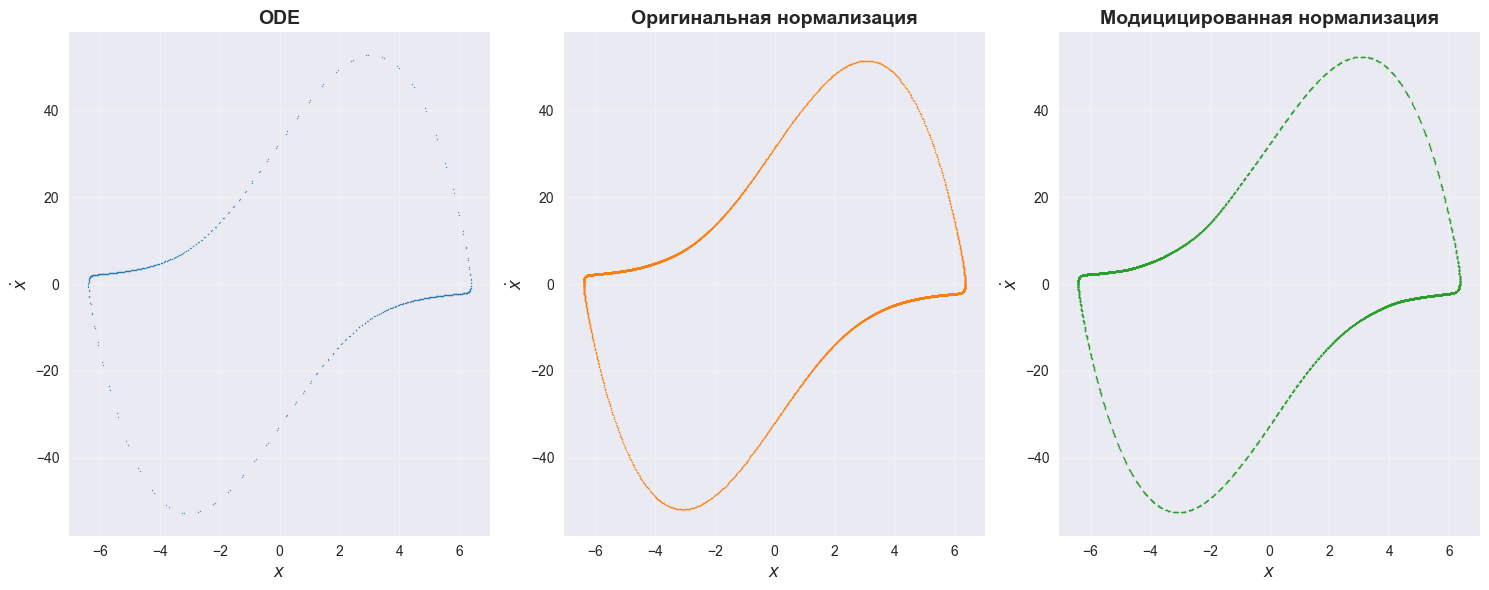

In [12]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import van_der_pol_rk4, van_der_pol_right_part

u0 = [0.5, 0.7]
p = [10, 10]

nm_long_traj = model_original.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)
nm_short_traj = fixed_model.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)
ode_traj = get_attractor_trajectory(
    van_der_pol_rk4, van_der_pol_right_part, u0, p, 0.01, 50, 50, 
    lambda x, y: x[1], lambda x, y: [0, 1], divergence_threshold=1e3
)

if nm_long_traj is not None:
    nm_long_traj = nm_long_traj[10000:]
if nm_short_traj is not None:
    nm_short_traj = nm_short_traj[10000:]

plot_compare_trajectories(
    ode_traj, nm_long_traj, nm_short_traj, 
    labels=['ODE', 'Оригинальная нормализация', 'Модицицированная нормализация'],
    layout='sidebyside'
)